Tuning learning rates for m=10000, sigma=5.0, steps=10

Detected sigma>0: Tuning learning rates independently for each algorithm

[1/3] Tuning Noisy Gradient Algorithm...
  Best lr_noisy = 0.0615, avg_final_loss = 5700.802692

[2/3] Tuning James-Stein Algorithm...
  Best lr_js = 1.0000, avg_final_loss = 5788.805767

[3/3] Tuning True Gradient Algorithm...
  Best lr_true = 1.0000, avg_final_loss = 0.000000

Running final experiment with tuned learning rates
Learning rates: lr_noisy=0.0615, lr_js=1.0000, lr_true=1.0000


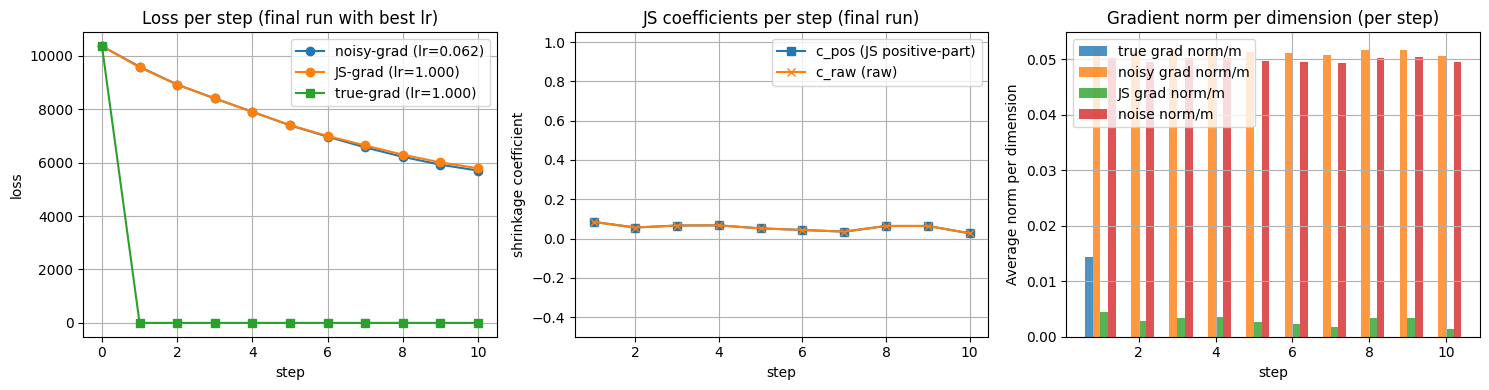


Final run summary (per-step):
 step  1: c_pos=0.084709, c_raw=0.084709, loss_noisy=9587.881705, loss_js=9566.264628, loss_true=0.000000, norm_true/m=0.014392, norm_noisy/m=0.052257, norm_js/m=0.004427, norm_noise/m=0.050199
 step  2: c_pos=0.056086, c_raw=0.056086, loss_noisy=8919.793414, loss_js=8916.649082, loss_true=0.000000, norm_true/m=0.000000, norm_noisy/m=0.051453, norm_js/m=0.002886, norm_noise/m=0.049590
 step  3: c_pos=0.066280, c_raw=0.066280, loss_noisy=8401.062324, loss_js=8399.573571, loss_true=0.000000, norm_true/m=0.000000, norm_noisy/m=0.051737, norm_js/m=0.003429, norm_noise/m=0.050218
 step  4: c_pos=0.067002, c_raw=0.067002, loss_noisy=7902.623313, loss_js=7895.695879, loss_true=0.000000, norm_true/m=0.000000, norm_noisy/m=0.051727, norm_js/m=0.003468, norm_noise/m=0.050171
 step  5: c_pos=0.051649, c_raw=0.051649, loss_noisy=7393.552892, loss_js=7401.947206, loss_true=0.000000, norm_true/m=0.000000, norm_noisy/m=0.051340, norm_js/m=0.002652, norm_noise/m=0.049661

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def james_stein_positive(vec, sigma2):
    m = vec.size
    norm2 = np.sum(vec**2)
    if norm2 == 0:
        c_raw = -np.inf
    else:
        c_raw = 1.0 - (m - 2) * sigma2 / norm2
    c_pos = max(c_raw, 0.0)
    return c_pos * vec, c_pos, c_raw

def loss(x, theta):
    return 0.5 * np.sum((x - theta)**2)

def true_grad(x, theta):
    return x - theta

def run_trajectory(m, theta, x_init, sigma, lr_noisy, lr_js, lr_true, steps, rng):
    """
    Run three independent experiments for `steps` updates:
      - Noisy experiment: update with lr_noisy * (g_true_noisy + noise)
      - JS experiment: update with lr_js * JS_estimator(g_true_js + noise)
      - True experiment: update with lr_true * g_true_true (no noise)
    Each experiment computes gradient at its own current position.
    Noisy and JS experiments share the same noise sequence for fair comparison.
    Returns arrays: losses_noisy (len steps+1), losses_js, losses_true, c_pos_list, etc.
    """
    x_noisy = x_init.copy()
    x_js = x_init.copy()
    x_true = x_init.copy()
    sigma2 = sigma**2

    losses_noisy = [loss(x_noisy, theta)]
    losses_js = [loss(x_js, theta)]
    losses_true = [loss(x_true, theta)]
    c_pos_list = []
    c_raw_list = []
    norm_true_list = []
    norm_noisy_list = []
    norm_js_list = []
    norm_noise_list = []

    for t in range(steps):
        # 1. Generate shared noise (used for Noisy and JS experiments)
        noise = rng.normal(0.0, sigma, size=m)

        # 2. Noisy experiment (independent)
        g_true_noisy = true_grad(x_noisy, theta)
        G_noisy = g_true_noisy + noise
        x_noisy = x_noisy - lr_noisy * G_noisy
        losses_noisy.append(loss(x_noisy, theta))

        # 3. JS experiment (independent)
        g_true_js = true_grad(x_js, theta)
        G_js = g_true_js + noise  # Use the same noise
        JS_est, c_pos, c_raw = james_stein_positive(G_js, sigma2)
        x_js = x_js - lr_js * JS_est
        losses_js.append(loss(x_js, theta))

        # 4. True experiment (independent, no noise)
        g_true_true = true_grad(x_true, theta)
        x_true = x_true - lr_true * g_true_true
        losses_true.append(loss(x_true, theta))

        # 5. Record statistics
        c_pos_list.append(c_pos)
        c_raw_list.append(c_raw)
        norm_true_list.append(np.linalg.norm(g_true_true) / m)
        norm_noisy_list.append(np.linalg.norm(G_noisy) / m)
        norm_js_list.append(np.linalg.norm(JS_est) / m)
        norm_noise_list.append(np.linalg.norm(noise) / m)

    return np.array(losses_noisy), np.array(losses_js), np.array(losses_true), np.array(c_pos_list), np.array(c_raw_list), np.array(norm_true_list), np.array(norm_noisy_list), np.array(norm_js_list), np.array(norm_noise_list)

def tune_lr_noisy(
    m=12,
    sigma=3.0,
    steps=10,
    seeds=(1,2,3,4,5),
    lr_noisy_grid=None
):
    """
    Grid search for optimal learning rate for noisy gradient algorithm.
    Optimizes lr_noisy to minimize losses_noisy[-1].
    """
    if lr_noisy_grid is None:
        lr_noisy_grid = np.linspace(0.01, 0.2, 100)

    best = None
    results = []

    for lr_noisy in lr_noisy_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            # Use dummy values for lr_js and lr_true since we only care about noisy trajectory
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(m, theta, x_init, sigma, lr_noisy, 0.1, 0.1, steps, rng)
            final_losses.append(losses_noisy[-1])
        avg_final_noisy_loss = float(np.mean(final_losses))
        results.append((lr_noisy, avg_final_noisy_loss))
        if (best is None) or (avg_final_noisy_loss < best[1]):
            best = (lr_noisy, avg_final_noisy_loss)
    return best, results

def tune_lr_js(
    m=12,
    sigma=3.0,
    steps=10,
    seeds=(1,2,3,4,5),
    lr_js_grid=None
):
    """
    Grid search for optimal learning rate for JS algorithm.
    Optimizes lr_js to minimize losses_js[-1].
    """
    if lr_js_grid is None:
        lr_js_grid = np.linspace(0.01, 0.2, 100)

    best = None
    results = []

    for lr_js in lr_js_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            # Use dummy values for lr_noisy and lr_true since we only care about JS trajectory
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(m, theta, x_init, sigma, 0.1, lr_js, 0.1, steps, rng)
            final_losses.append(losses_js[-1])
        avg_final_js_loss = float(np.mean(final_losses))
        results.append((lr_js, avg_final_js_loss))
        if (best is None) or (avg_final_js_loss < best[1]):
            best = (lr_js, avg_final_js_loss)
    return best, results

def tune_lr_true(
    m=12,
    sigma=3.0,
    steps=10,
    seeds=(1,2,3,4,5),
    lr_true_grid=None
):
    """
    Grid search for optimal learning rate for true gradient trajectory.
    """
    if lr_true_grid is None:
        lr_true_grid = np.linspace(0.01, 0.2, 100)  # candidate lr for true gradient trajectory
    
    best = None
    results = []
    
    for lr_true in lr_true_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            # Use dummy values for lr_noisy and lr_js since we only care about true trajectory
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(m, theta, x_init, sigma, 0.1, 0.2, lr_true, steps, rng)
            final_losses.append(losses_true[-1])
        avg_final_true_loss = float(np.mean(final_losses))
        results.append((lr_true, avg_final_true_loss))
        if (best is None) or (avg_final_true_loss < best[1]):
            best = (lr_true, avg_final_true_loss)
    return best, results

if __name__ == "__main__":
    # -------------------- user-tunable parameters --------------------
    m = 10000
    sigma = 5.0
    steps = 10
    seeds = (999,)   # single seed for tuning
    # lr grids (you can adjust ranges)
    lr_grid = np.linspace(0.001, 1.0, 100)
    # ----------------------------------------------------------------

    print("="*70)
    print(f"Tuning learning rates for m={m}, sigma={sigma}, steps={steps}")
    print("="*70)
    
   
    
    print("\nDetected sigma>0: Tuning learning rates independently for each algorithm")
    
    print("\n[1/3] Tuning Noisy Gradient Algorithm...")
    best_noisy, all_results_noisy = tune_lr_noisy(
        m=m,
        sigma=sigma,
        steps=steps,
        seeds=seeds,
        lr_noisy_grid=lr_grid
    )
    
    if best_noisy is None:
        print("Tuning for noisy algorithm failed.")
        raise SystemExit(1)
    
    best_lr_noisy, best_avg_noisy_loss = best_noisy
    print(f"  Best lr_noisy = {best_lr_noisy:.4f}, avg_final_loss = {best_avg_noisy_loss:.6f}")
    
    print("\n[2/3] Tuning James-Stein Algorithm...")
    best_js, all_results_js = tune_lr_js(
        m=m,
        sigma=sigma,
        steps=steps,
        seeds=seeds,
        lr_js_grid=lr_grid
    )
    
    if best_js is None:
        print("Tuning for JS algorithm failed.")
        raise SystemExit(1)
    
    best_lr_js, best_avg_js_loss = best_js
    print(f"  Best lr_js = {best_lr_js:.4f}, avg_final_loss = {best_avg_js_loss:.6f}")
    
    print("\n[3/3] Tuning True Gradient Algorithm...")
    best_true, all_results_true = tune_lr_true(
        m=m,
        sigma=sigma,
        steps=steps,
        seeds=seeds,
        lr_true_grid=lr_grid
    )
    
    if best_true is None:
        print("Tuning for true gradient algorithm failed.")
        raise SystemExit(1)
    
    best_lr_true, best_avg_true_loss = best_true
    print(f"  Best lr_true = {best_lr_true:.4f}, avg_final_loss = {best_avg_true_loss:.6f}")
    
    print("\n" + "="*70)
    print("Running final experiment with tuned learning rates")
    print("="*70)
    print(f"Learning rates: lr_noisy={best_lr_noisy:.4f}, lr_js={best_lr_js:.4f}, lr_true={best_lr_true:.4f}")
    
    # Run a final illustrative run with the best learning rates
    seed_final = 999
    rng = np.random.RandomState(seed_final)
    theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
    x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))

    losses_noisy, losses_js, losses_true, c_pos_list, c_raw_list, norm_true_list, norm_noisy_list, norm_js_list, norm_noise_list = run_trajectory(
        m, theta, x_init, sigma, best_lr_noisy, best_lr_js, best_lr_true, steps, rng
    )

    # Plot 1: Loss per step
    steps_range = np.arange(0, steps+1)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.plot(steps_range, losses_noisy, marker='o', label=f'noisy-grad (lr={best_lr_noisy:.3f})')
    plt.plot(steps_range, losses_js, marker='o', label=f'JS-grad (lr={best_lr_js:.3f})')
    plt.plot(steps_range, losses_true, marker='s', label=f'true-grad (lr={best_lr_true:.3f})')
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Loss per step (final run with best lr)")
    plt.legend()
    plt.grid(True)

    # Plot 2: JS shrinkage coefficient per step
    plt.subplot(1,3,2)
    plt.plot(np.arange(1, steps+1), c_pos_list, marker='s', label='c_pos (JS positive-part)')
    plt.plot(np.arange(1, steps+1), c_raw_list, marker='x', label='c_raw (raw)')
    plt.xlabel("step")
    plt.ylabel("shrinkage coefficient")
    plt.title("JS coefficients per step (final run)")
    plt.ylim(-0.5, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot 3: Gradient L2 norm per step
    plt.subplot(1,3,3)
    steps_range_bar = np.arange(1, steps+1)
    width = 0.2
    plt.bar(steps_range_bar - 1.5*width, norm_true_list, width, label='true grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar - 0.5*width, norm_noisy_list, width, label='noisy grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 0.5*width, norm_js_list, width, label='JS grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 1.5*width, norm_noise_list, width, label='noise norm/m', alpha=0.8)
    plt.xlabel("step")
    plt.ylabel("Average norm per dimension")
    plt.title("Gradient norm per dimension (per step)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print short summary
    print("\nFinal run summary (per-step):")
    for t in range(steps):
        print(f" step {t+1:2d}: c_pos={c_pos_list[t]:.6f}, c_raw={c_raw_list[t]:.6f}, loss_noisy={losses_noisy[t+1]:.6f}, loss_js={losses_js[t+1]:.6f}, loss_true={losses_true[t+1]:.6f}, norm_true/m={norm_true_list[t]:.6f}, norm_noisy/m={norm_noisy_list[t]:.6f}, norm_js/m={norm_js_list[t]:.6f}, norm_noise/m={norm_noise_list[t]:.6f}")

    # Verification for sigma=0
    if sigma == 0.0:
        print("\n" + "="*70)
        print("VERIFICATION (sigma=0)")
        print("="*70)
        max_diff_nj = np.max(np.abs(losses_noisy - losses_js))
        max_diff_jt = np.max(np.abs(losses_js - losses_true))
        print(f"Max difference (Noisy vs JS): {max_diff_nj:.2e}")
        print(f"Max difference (JS vs True): {max_diff_jt:.2e}")
        
        if np.allclose(losses_noisy, losses_js) and np.allclose(losses_js, losses_true):
            print("✓ SUCCESS: All three algorithms produce identical results!")
        else:
            print("✗ WARNING: Results differ (this should not happen when sigma=0 and lr are equal)")
    
    print("\nDone.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def james_stein_positive(vec, sigma2):
    m = vec.size
    norm2 = np.sum(vec**2)
    if norm2 == 0:
        c_raw = -np.inf
    else:
        c_raw = 1.0 - (m - 2) * sigma2 / norm2
    c_pos = max(c_raw, 0.0)
    return c_pos * vec, c_pos, c_raw

def softmax(logits):
    """Numerically stable softmax"""
    logits_max = np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits - logits_max)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(W_flat, X_data, y_data, input_dim, n_classes):
    """Cross-entropy loss for multi-class classification"""
    W = W_flat.reshape(input_dim, n_classes)
    logits = X_data @ W  # (n_samples, n_classes)
    
    # Numerically stable cross-entropy using logsumexp
    logits_max = np.max(logits, axis=1, keepdims=True)
    log_sum_exp = np.log(np.sum(np.exp(logits - logits_max), axis=1)) + logits_max.squeeze()
    
    # Extract logits for true classes
    logits_true = logits[np.arange(len(y_data)), y_data]
    
    # Cross-entropy: -mean(log(p_true)) = mean(log_sum_exp - logit_true)
    loss = np.mean(log_sum_exp - logits_true)
    return loss

def cross_entropy_grad(W_flat, X_data, y_data, input_dim, n_classes):
    """Gradient of cross-entropy loss w.r.t. W"""
    n_samples = len(y_data)
    W = W_flat.reshape(input_dim, n_classes)
    logits = X_data @ W  # (n_samples, n_classes)
    
    # Compute softmax probabilities
    probs = softmax(logits)  # (n_samples, n_classes)
    
    # Subtract 1 from true class probabilities
    probs[np.arange(n_samples), y_data] -= 1
    
    # Gradient: X.T @ (probs - one_hot(y)) / n_samples
    grad_W = X_data.T @ probs / n_samples  # (input_dim, n_classes)
    
    return grad_W.flatten()

def run_trajectory(m, theta, x_init, sigma, lr_noisy, lr_js, lr_true, steps, rng,
                   X_data, y_data, input_dim, n_classes):
    """
    Run three independent experiments for `steps` updates:
      - Noisy experiment: update with lr_noisy * (g_true_noisy + noise)
      - JS experiment: update with lr_js * JS_estimator(g_true_js + noise)
      - True experiment: update with lr_true * g_true_true (no noise)
    Each experiment computes gradient at its own current position.
    Noisy and JS experiments share the same noise sequence for fair comparison.
    Returns arrays: losses_noisy (len steps+1), losses_js, losses_true, c_pos_list, etc.
    """
    x_noisy = x_init.copy()
    x_js = x_init.copy()
    x_true = x_init.copy()
    sigma2 = sigma**2

    losses_noisy = [cross_entropy_loss(x_noisy, X_data, y_data, input_dim, n_classes)]
    losses_js = [cross_entropy_loss(x_js, X_data, y_data, input_dim, n_classes)]
    losses_true = [cross_entropy_loss(x_true, X_data, y_data, input_dim, n_classes)]
    c_pos_list = []
    c_raw_list = []
    norm_true_list = []
    norm_noisy_list = []
    norm_js_list = []
    norm_noise_list = []

    for t in range(steps):
        # 1. Generate shared noise (used for Noisy and JS experiments)
        noise = rng.normal(0.0, sigma, size=m)

        # 2. Noisy experiment (independent)
        g_true_noisy = cross_entropy_grad(x_noisy, X_data, y_data, input_dim, n_classes)
        G_noisy = g_true_noisy + noise
        x_noisy = x_noisy - lr_noisy * G_noisy
        losses_noisy.append(cross_entropy_loss(x_noisy, X_data, y_data, input_dim, n_classes))

        # 3. JS experiment (independent)
        g_true_js = cross_entropy_grad(x_js, X_data, y_data, input_dim, n_classes)
        G_js = g_true_js + noise  # Use the same noise
        JS_est, c_pos, c_raw = james_stein_positive(G_js, sigma2)
        x_js = x_js - lr_js * JS_est
        losses_js.append(cross_entropy_loss(x_js, X_data, y_data, input_dim, n_classes))

        # 4. True experiment (independent, no noise)
        g_true_true = cross_entropy_grad(x_true, X_data, y_data, input_dim, n_classes)
        x_true = x_true - lr_true * g_true_true
        losses_true.append(cross_entropy_loss(x_true, X_data, y_data, input_dim, n_classes))

        # 5. Record statistics
        c_pos_list.append(c_pos)
        c_raw_list.append(c_raw)
        norm_true_list.append(np.linalg.norm(g_true_true) / m)
        norm_noisy_list.append(np.linalg.norm(G_noisy) / m)
        norm_js_list.append(np.linalg.norm(JS_est) / m)
        norm_noise_list.append(np.linalg.norm(noise) / m)

    return np.array(losses_noisy), np.array(losses_js), np.array(losses_true), np.array(c_pos_list), np.array(c_raw_list), np.array(norm_true_list), np.array(norm_noisy_list), np.array(norm_js_list), np.array(norm_noise_list)

def tune_lr_noisy(input_dim=1000, n_classes=10, sigma=3.0, steps=10, 
                  seeds=(1,2,3,4,5), lr_grid=None, n_samples=500):
    """Tune learning rate for noisy gradient algorithm"""
    if lr_grid is None:
        lr_grid = np.linspace(0.001, 0.05, 100)
    
    best = None
    
    for lr in lr_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            m = input_dim * n_classes
            
            # Generate data
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            X_data = rng.randn(n_samples, input_dim)
            W_theta = theta.reshape(input_dim, n_classes)
            logits_theta = X_data @ W_theta
            y_data = np.argmax(logits_theta, axis=1)
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            
            # Run trajectory with dummy lr_js and lr_true
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(
                m, theta, x_init, sigma, lr, 0.1, 0.1, steps, rng,
                X_data, y_data, input_dim, n_classes
            )
            final_losses.append(losses_noisy[-1])
        
        avg_final_loss = float(np.mean(final_losses))
        if (best is None) or (avg_final_loss < best[1]):
            best = (lr, avg_final_loss)
    
    return best

def tune_lr_js(input_dim=1000, n_classes=10, sigma=3.0, steps=10,
               seeds=(1,2,3,4,5), lr_grid=None, n_samples=500):
    """Tune learning rate for JS algorithm"""
    if lr_grid is None:
        lr_grid = np.linspace(0.001, 0.05, 100)
    
    best = None
    
    for lr in lr_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            m = input_dim * n_classes
            
            # Generate data
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            X_data = rng.randn(n_samples, input_dim)
            W_theta = theta.reshape(input_dim, n_classes)
            logits_theta = X_data @ W_theta
            y_data = np.argmax(logits_theta, axis=1)
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            
            # Run trajectory with dummy lr_noisy and lr_true
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(
                m, theta, x_init, sigma, 0.1, lr, 0.1, steps, rng,
                X_data, y_data, input_dim, n_classes
            )
            final_losses.append(losses_js[-1])
        
        avg_final_loss = float(np.mean(final_losses))
        if (best is None) or (avg_final_loss < best[1]):
            best = (lr, avg_final_loss)
    
    return best

def tune_lr_true(input_dim=1000, n_classes=10, steps=10,
                 seeds=(1,2,3,4,5), lr_grid=None, n_samples=500):
    """Tune learning rate for true gradient algorithm"""
    if lr_grid is None:
        lr_grid = np.linspace(0.001, 0.05, 100)
    
    best = None
    
    for lr in lr_grid:
        final_losses = []
        for sd in seeds:
            rng = np.random.RandomState(sd)
            m = input_dim * n_classes
            
            # Generate data
            theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
            X_data = rng.randn(n_samples, input_dim)
            W_theta = theta.reshape(input_dim, n_classes)
            logits_theta = X_data @ W_theta
            y_data = np.argmax(logits_theta, axis=1)
            x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))
            
            # Run trajectory with dummy lr_noisy and lr_js
            losses_noisy, losses_js, losses_true, _, _, _, _, _, _ = run_trajectory(
                m, theta, x_init, sigma, 0.1, 0.1, lr, steps, rng,
                X_data, y_data, input_dim, n_classes
            )
            final_losses.append(losses_true[-1])
        
        avg_final_loss = float(np.mean(final_losses))
        if (best is None) or (avg_final_loss < best[1]):
            best = (lr, avg_final_loss)
    
    return best

if __name__ == "__main__":
    # -------------------- user-tunable parameters --------------------
    input_dim = 1000
    n_classes = 10
    m = input_dim * n_classes  # 10000
    n_samples = 500
    sigma = 3.0
    steps = 10
    seeds = (999,)   # single seed for tuning
    
    # lr grids
    lr_grid = np.linspace(0.001, 0.05, 20)
    # ----------------------------------------------------------------

    print("="*70)
    print(f"Tuning learning rates for m={m}, sigma={sigma}, steps={steps}")
    print("="*70)
    
    print("\n[1/3] Tuning Noisy Gradient Algorithm...")
    best_lr_noisy, best_avg_noisy_loss = tune_lr_noisy(
        input_dim=input_dim, n_classes=n_classes, sigma=sigma, steps=steps,
        seeds=seeds, lr_grid=lr_grid, n_samples=n_samples
    )
    print(f"  Best lr_noisy = {best_lr_noisy:.4f}, avg_final_loss = {best_avg_noisy_loss:.6f}")
    
    print("\n[2/3] Tuning James-Stein Algorithm...")
    best_lr_js, best_avg_js_loss = tune_lr_js(
        input_dim=input_dim, n_classes=n_classes, sigma=sigma, steps=steps,
        seeds=seeds, lr_grid=lr_grid, n_samples=n_samples
    )
    print(f"  Best lr_js = {best_lr_js:.4f}, avg_final_loss = {best_avg_js_loss:.6f}")
    
    print("\n[3/3] Tuning True Gradient Algorithm...")
    best_lr_true, best_avg_true_loss = tune_lr_true(
        input_dim=input_dim, n_classes=n_classes, steps=steps,
        seeds=seeds, lr_grid=lr_grid, n_samples=n_samples
    )
    print(f"  Best lr_true = {best_lr_true:.4f}, avg_final_loss = {best_avg_true_loss:.6f}")
    
    print("\n" + "="*70)
    print("Running final experiment with tuned learning rates")
    print("="*70)
    print(f"Learning rates: lr_noisy={best_lr_noisy:.4f}, lr_js={best_lr_js:.4f}, lr_true={best_lr_true:.4f}")
    
    # Run a final illustrative run with the best learning rates
    seed_final = 999
    rng = np.random.RandomState(seed_final)
    theta = 0.5 * np.sin(np.linspace(0, 3*np.pi, m))
    X_data = rng.randn(n_samples, input_dim)
    W_theta = theta.reshape(input_dim, n_classes)
    logits_theta = X_data @ W_theta
    y_data = np.argmax(logits_theta, axis=1)
    x_init = 1.5 + 0.8 * np.cos(np.linspace(0, 2*np.pi, m))

    losses_noisy, losses_js, losses_true, c_pos_list, c_raw_list, norm_true_list, norm_noisy_list, norm_js_list, norm_noise_list = run_trajectory(
        m, theta, x_init, sigma, best_lr_noisy, best_lr_js, best_lr_true, steps, rng,
        X_data, y_data, input_dim, n_classes
    )

    # Plot 1: Loss per step
    steps_range = np.arange(0, steps+1)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.plot(steps_range, losses_noisy, marker='o', label=f'noisy-grad (lr={best_lr_noisy:.3f})')
    plt.plot(steps_range, losses_js, marker='o', label=f'JS-grad (lr={best_lr_js:.3f})')
    plt.plot(steps_range, losses_true, marker='s', label=f'true-grad (lr={best_lr_true:.3f})')
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Loss per step (final run with best lr)")
    plt.legend()
    plt.grid(True)

    # Plot 2: JS shrinkage coefficient per step
    plt.subplot(1,3,2)
    plt.plot(np.arange(1, steps+1), c_pos_list, marker='s', label='c_pos (JS positive-part)')
    plt.plot(np.arange(1, steps+1), c_raw_list, marker='x', label='c_raw (raw)')
    plt.xlabel("step")
    plt.ylabel("shrinkage coefficient")
    plt.title("JS coefficients per step (final run)")
    plt.ylim(-0.5, 1.05)
    plt.legend()
    plt.grid(True)

    # Plot 3: Gradient L2 norm per step
    plt.subplot(1,3,3)
    steps_range_bar = np.arange(1, steps+1)
    width = 0.2
    plt.bar(steps_range_bar - 1.5*width, norm_true_list, width, label='true grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar - 0.5*width, norm_noisy_list, width, label='noisy grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 0.5*width, norm_js_list, width, label='JS grad norm/m', alpha=0.8)
    plt.bar(steps_range_bar + 1.5*width, norm_noise_list, width, label='noise norm/m', alpha=0.8)
    plt.xlabel("step")
    plt.ylabel("Average norm per dimension")
    plt.title("Gradient norm per dimension (per step)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print short summary
    print("\nFinal run summary (per-step):")
    for t in range(steps):
        print(f" step {t+1:2d}: c_pos={c_pos_list[t]:.6f}, c_raw={c_raw_list[t]:.6f}, loss_noisy={losses_noisy[t+1]:.6f}, loss_js={losses_js[t+1]:.6f}, loss_true={losses_true[t+1]:.6f}, norm_true/m={norm_true_list[t]:.6f}, norm_noisy/m={norm_noisy_list[t]:.6f}, norm_js/m={norm_js_list[t]:.6f}, norm_noise/m={norm_noise_list[t]:.6f}")

    # Verification for sigma=0
    if sigma == 0.0:
        print("\n" + "="*70)
        print("VERIFICATION (sigma=0)")
        print("="*70)
        max_diff_nj = np.max(np.abs(losses_noisy - losses_js))
        max_diff_jt = np.max(np.abs(losses_js - losses_true))
        print(f"Max difference (Noisy vs JS): {max_diff_nj:.2e}")
        print(f"Max difference (JS vs True): {max_diff_jt:.2e}")
        
        if np.allclose(losses_noisy, losses_js) and np.allclose(losses_js, losses_true):
            print("✓ SUCCESS: All three algorithms produce identical results!")
        else:
            print("✗ WARNING: Results differ (this should not happen when sigma=0 and lr are equal)")
    
    print("\nDone.")